# 🚦 Traffic Accident Hotspot Detection and Severity Prediction
## Notebook 02: Exploratory Data Analysis (EDA)

---

| | |
|---|---|
| **Dataset** | US Accidents (2016–2023), 300,000-row reproducible sample |
| **Environment** | Google Colab |
| **Notebook Role** | Exploratory Data Analysis ONLY |
| **Pipeline Position** | 2 of 6 |
| **Depends on** | `01_Dataset_Understanding.ipynb` findings |

---

## 🎯 Objective

Notebook 01 told us *what* is in the dataset — column meanings, types, missing values, memory footprint. This notebook asks a different question:

> "What **patterns, trends, and relationships** exist in the data — and what do they mean for the model we're eventually going to build?"

**Strict scope for this notebook:**
- ✅ Visual and statistical exploration only
- ✅ Every chart gets a written interpretation: what it shows, why it matters, and how it will influence later notebooks
- ❌ No missing value handling (→ Notebook 03: Cleaning), encoding, or scaling (→ Notebook 06: Encoding, Scaling, ML)
- ❌ No new engineered features saved for modeling (→ Notebook 04: Feature Engineering)
- ❌ No model training of any kind (→ Notebooks 05–06)

**Important note on datetime columns**: Some visualizations below (accidents by year/month/hour, etc.) need `Start_Time` broken into parts like hour and day-of-week. We do this **locally, temporarily, and only for plotting** in this notebook — these derived columns are never saved to disk and are not treated as the "official" cleaned/engineered version of the data. The formal, robust datetime parsing (handling malformed timestamps, timezone edge cases, etc.) is a Notebook 03 responsibility. This is a common and accepted practice in EDA notebooks: light, disposable transformations purely to enable visualization are not the same as the pipeline's formal preprocessing stage.

## 1. Import Libraries

**Objective:** Load only what's needed for visualization and light statistical exploration.

**Why these specific libraries:**
- `pandas`, `numpy` — data handling (same as Notebook 01)
- `matplotlib`, `seaborn` — used for the correlation heatmap and a couple of static, publication-style plots where Plotly is unnecessary overhead
- `plotly.express` / `plotly.graph_objects` — used for the majority of charts here, because Plotly renders interactively (zoom, hover tooltips) and handles large datasets more gracefully than Matplotlib for bar/histogram/map plots — useful both for our own exploration and for a more impressive GitHub/portfolio presentation
- `warnings` — suppressed only for non-critical library version warnings, not for errors

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# Consistent visual style across all Matplotlib/Seaborn plots
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)

print("Libraries imported successfully.")

Libraries imported successfully.


**Explanation:**
- `warnings.filterwarnings('ignore')` — suppresses harmless deprecation/version warnings that clutter output in Colab; this does NOT hide actual errors, only non-critical warnings.
- `sns.set_style('whitegrid')` — sets a clean, consistent background grid for all Matplotlib/Seaborn charts, so the notebook has a uniform, professional look throughout.
- `plt.rcParams['figure.dpi'] = 100` — ensures static plots render at a crisp resolution suitable for a report or GitHub README screenshot.

**Common Mistakes:** Suppressing warnings globally without knowing what you're hiding — always understand what a warning says at least once before silencing it project-wide.

**Best Practices:** Keep style/display settings in one place at the top of the notebook, exactly like this, so formatting stays consistent without repeating code in every section.

## 2. Load Dataset

**Objective:** Recreate the *exact same* 300,000-row sample used in Notebook 01.

**Why we reload instead of assuming it's "already in memory":** Each Colab notebook runs in its own independent runtime/session. Notebook 01's variables do not carry over to Notebook 02 automatically. To guarantee we're analyzing the identical dataset (not a new random sample), we repeat the same loading logic — same columns, same `SAMPLE_SIZE`, same `random_state=42` — exactly as documented in Notebook 01. This reproducibility is the entire point of fixing a random seed.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/US_Accidents_March23.csv"

# Identical column selection to Notebook 01 -- see that notebook for
# the full justification of why these columns were chosen
usecols = [
    'ID', 'Source', 'Severity', 'Start_Time', 'End_Time',
    'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)',
    'City', 'County', 'State', 'Zipcode', 'Timezone',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition',
    'Amenity', 'Crossing', 'Junction', 'Railway', 'Station',
    'Stop', 'Traffic_Signal', 'Sunrise_Sunset'
]

df_full = pd.read_csv(DATA_PATH, usecols=usecols)

SAMPLE_SIZE = 300_000
df = df_full.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
del df_full

print(f"Dataset reloaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("This should exactly match Notebook 01's shape: 300,000 rows, 31 columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset reloaded: 300,000 rows, 31 columns
This should exactly match Notebook 01's shape: 300,000 rows, 31 columns


**Expected Output:**
```
Dataset reloaded: 300,000 rows, 31 columns
This should exactly match Notebook 01's shape: 300,000 rows, 31 columns
```

**Common Mistakes:** Changing `random_state` or `SAMPLE_SIZE` "by accident" between notebooks — this silently breaks reproducibility and means findings from Notebook 01 no longer apply to what you're analyzing now.

**Best Practices:** Copy the loading logic verbatim between notebooks rather than retyping it from memory, to eliminate any risk of subtle mismatches.

## 3. Severity Distribution

**Objective:** Visualize the class balance of our target variable in a form suitable for a report — Notebook 01 already reported the numbers, this section makes it visually unmistakable.

In [6]:
severity_counts = df['Severity'].value_counts().sort_index().reset_index()
severity_counts.columns = ['Severity', 'Count']

fig = px.bar(
    severity_counts, x='Severity', y='Count', text='Count',
    color='Severity', color_continuous_scale='Reds',
    title='Distribution of Accident Severity Levels',
    labels={'Severity': 'Severity Level (1 = Minor, 4 = Severe)', 'Count': 'Number of Accidents'}
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**What is observed:** Severity level 2 dominates the dataset by a wide margin, with Severity 1 being extremely rare and Severity 3/4 forming smaller minority groups.

**Why it is important:** This confirms, visually, the class imbalance flagged numerically in Notebook 01. A model trained naively on this distribution could achieve high *accuracy* just by always predicting Severity 2 — while being practically useless at identifying the rare, high-impact Severity 4 cases, which are arguably the ones that matter most for a real-world hotspot/risk system.

**How it will influence future preprocessing/ML:** In Notebook 06 (Severity Prediction), we will need to use metrics like F1-score, per-class recall, or a confusion matrix rather than plain accuracy. We may also consider class-weighting or resampling techniques (Notebook 04/06 decision) specifically because of this imbalance.

## 4. Accidents by Year

**Objective:** Understand how accident volume in our sample trends across the 2016–2023 range.

We extract `Year` from `Start_Time` here **temporarily, for visualization only** (see the Important Note in the introduction).

In [7]:
# Temporary, EDA-only datetime parsing -- not saved for downstream notebooks
start_time_parsed = pd.to_datetime(df['Start_Time'], errors='coerce')

yearly_counts = start_time_parsed.dt.year.value_counts().sort_index().reset_index()
yearly_counts.columns = ['Year', 'Count']

fig = px.line(
    yearly_counts, x='Year', y='Count', markers=True,
    title='Accident Volume by Year (2016–2023 Sample)',
    labels={'Year': 'Year', 'Count': 'Number of Accidents'}
)
fig.update_layout(title_x=0.5)
fig.show()

**Explanation of code:** `pd.to_datetime(..., errors='coerce')` converts the text `Start_Time` column into real datetime objects; `errors='coerce'` means any unparseable value becomes `NaT` (Not a Time) instead of crashing the whole conversion — a safe way to explore even if a few rows have malformed timestamps. We do NOT overwrite `df['Start_Time']` with this — we keep it in a separate variable, `start_time_parsed`, that only exists for this notebook's plotting needs.

**What is observed:** Accident counts typically show a strong upward trend in the earlier years as data coverage/reporting expanded, and may show a dip in 2020 (a known real-world effect — reduced traffic during COVID-19 lockdowns).

**Why it is important:** This tells us the dataset isn't uniformly distributed across years — some years are naturally over/under-represented due to real-world events, not data quality issues.

**How it will influence future preprocessing/ML:** If year-driven trends are strong, `Year` (or a derived "years since 2016" feature) may be worth including as a feature in Notebook 04, and we should be cautious about any train/test split strategy in Notebook 06 that could let a model "leak" information across time inappropriately (e.g., informing on later years' patterns from earlier years alone).

## 5. Accidents by Month

**Objective:** Check for seasonal accident patterns.

In [8]:
monthly_counts = start_time_parsed.dt.month.value_counts().sort_index().reset_index()
monthly_counts.columns = ['Month', 'Count']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_counts['Month_Name'] = monthly_counts['Month'].astype(int).apply(lambda m: month_names[m-1])

fig = px.bar(
    monthly_counts, x='Month_Name', y='Count', text='Count',
    title='Accident Volume by Month (Seasonality Check)',
    labels={'Month_Name': 'Month', 'Count': 'Number of Accidents'},
    color='Count', color_continuous_scale='Blues'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5, xaxis={'categoryorder': 'array', 'categoryarray': month_names})
fig.show()

**What is observed:** Winter months (especially December, January, February) often show elevated accident counts, consistent with adverse weather conditions (snow, ice, reduced visibility) increasing accident risk.

**Why it is important:** This is a direct, visible link between our future weather features and accident frequency — it's not just a coincidence but a pattern grounded in real driving conditions.

**How it will influence future preprocessing/ML:** Supports including `Month` or a `Season` feature (Winter/Spring/Summer/Fall) in Notebook 04's feature engineering, since month alone carries real predictive signal.

## 6. Accidents by Day (Day of Week)

**Objective:** Understand which days of the week see the most accidents.

In [9]:
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = start_time_parsed.dt.dayofweek.value_counts().sort_index().reset_index()
dow_counts.columns = ['DOW', 'Count']
dow_counts['Day'] = dow_counts['DOW'].astype(int).apply(lambda d: day_names[d])

fig = px.bar(
    dow_counts, x='Day', y='Count', text='Count',
    title='Accident Volume by Day of Week',
    labels={'Day': 'Day of Week', 'Count': 'Number of Accidents'},
    color='Count', color_continuous_scale='Purples'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5, xaxis={'categoryorder': 'array', 'categoryarray': day_names})
fig.show()

**What is observed:** Weekdays (especially Tuesday–Friday) typically show noticeably higher accident counts than weekends, consistent with higher traffic volume during commute days.

**Why it is important:** Confirms that accident risk isn't just about road/weather conditions — human commuting behavior is a major driver of *when* accidents happen.

**How it will influence future preprocessing/ML:** `Day_of_Week` (or a binary `Is_Weekend` flag, explored fully next) is a strong candidate engineered feature for Notebook 04.

## 7. Accidents by Hour

**Objective:** Identify hourly rush-hour patterns — typically one of the strongest time-based signals in traffic accident data.

In [10]:
hourly_counts = start_time_parsed.dt.hour.value_counts().sort_index().reset_index()
hourly_counts.columns = ['Hour', 'Count']

fig = px.line(
    hourly_counts, x='Hour', y='Count', markers=True,
    title='Accident Volume by Hour of Day',
    labels={'Hour': 'Hour of Day (0–23)', 'Count': 'Number of Accidents'}
)
fig.update_layout(title_x=0.5)
fig.update_xaxes(dtick=1)
fig.show()

**What is observed:** A bimodal pattern is typically visible — sharp peaks around 7–9 AM and 4–6 PM, corresponding to morning and evening rush-hour commute windows, with a clear dip overnight.

**Why it is important:** This is one of the strongest and most intuitive patterns in the whole dataset — it directly reflects real-world traffic density, and validates that our data genuinely reflects real driving behavior rather than being artifactual or randomly distributed.

**How it will influence future preprocessing/ML:** `Hour` is very likely to become one of our most important engineered features in Notebook 04 — possibly bucketed into categories like "Morning Rush," "Evening Rush," "Night," "Off-Peak" rather than used as a raw 0–23 number, since the relationship with accident risk is cyclical, not linear.

## 8. Weekday vs Weekend

**Objective:** Simplify the day-of-week pattern into a direct two-group comparison, which is often a cleaner story for a report/presentation than 7 separate bars.

In [11]:
is_weekend = start_time_parsed.dt.dayofweek.isin([5, 6])
weekend_counts = is_weekend.value_counts().reset_index()
weekend_counts.columns = ['Is_Weekend', 'Count']
weekend_counts['Label'] = weekend_counts['Is_Weekend'].map({True: 'Weekend', False: 'Weekday'})

fig = px.pie(
    weekend_counts, names='Label', values='Count',
    title='Accident Share: Weekday vs Weekend',
    color='Label', color_discrete_map={'Weekday': '#4C72B0', 'Weekend': '#DD8452'}
)
fig.update_traces(textinfo='percent+label')
fig.update_layout(title_x=0.5)
fig.show()

**What is observed:** Weekdays typically account for a clearly larger share of accidents than weekends — often in a roughly 70/30 or similar split, given weekdays are 5 of 7 days AND carry more commute traffic.

**Why it is important:** Confirms commuting-driven traffic (not leisure/weekend driving) is the dominant contributor to accident volume in this dataset.

**How it will influence future preprocessing/ML:** Supports creating a simple binary `Is_Weekend` feature in Notebook 04 — simpler and potentially more robust for a model than using all 7 individual day categories, especially given our earlier finding that weekday accident counts are fairly similar to each other while weekend counts are consistently lower.

## 9. Weather Condition Analysis

**Objective:** Identify which weather conditions are most commonly associated with recorded accidents.

**Efficiency note:** `Weather_Condition` has dozens of unique text values (e.g., "Light Rain", "Heavy Snow", "Fog", etc.). We restrict this plot to the **top 15 most frequent conditions** rather than plotting all of them — this keeps the chart readable and avoids a cluttered, low-value visualization.

In [12]:
top_weather = df['Weather_Condition'].value_counts().head(15).reset_index()
top_weather.columns = ['Weather_Condition', 'Count']

fig = px.bar(
    top_weather.sort_values('Count'), x='Count', y='Weather_Condition',
    orientation='h', text='Count',
    title='Top 15 Most Common Weather Conditions During Accidents',
    labels={'Count': 'Number of Accidents', 'Weather_Condition': 'Weather Condition'},
    color='Count', color_continuous_scale='Teal'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5, height=500)
fig.show()

**What is observed:** "Clear" or "Fair" weather conditions are typically the single most common condition recorded during accidents — which can look counterintuitive at first glance (shouldn't bad weather cause more accidents?).

**Why it is important:** This is a classic case of needing to interpret raw frequency correctly: clear weather is simply far more common overall (most days are clear), so it naturally accumulates more total accidents even if the *rate* of accidents per clear-weather-day is lower than the rate per severe-weather-day. This is a genuinely useful insight to articulate in your report/viva — it shows you understand the difference between raw counts and risk rates, not just reading the chart at face value.

**How it will influence future preprocessing/ML:** `Weather_Condition` has high cardinality (many unique text categories) — grouping into broader buckets like "Clear," "Rain," "Snow," "Fog," "Other" is a candidate for Notebook 04's feature engineering, while the actual encoding strategy (e.g., avoiding naive one-hot encoding of every unique text value, which would create dozens of sparse, low-value columns) is applied in Notebook 06.

## 10. Temperature Distribution

**Objective:** Understand the range and shape of the `Temperature(F)` feature.

In [13]:
fig = px.histogram(
    df, x='Temperature(F)', nbins=60,
    title='Distribution of Temperature at Time of Accident',
    labels={'Temperature(F)': 'Temperature (°F)'},
    color_discrete_sequence=['indianred']
)
fig.update_layout(title_x=0.5, yaxis_title='Number of Accidents')
fig.show()

**What is observed:** Temperature typically follows a roughly bell-shaped distribution centered in the 50–70°F range, with a long tail toward both extreme cold and extreme heat.

**Why it is important:** Extreme values in either direction may correspond to more hazardous driving conditions (ice at low temps, heat-related tire/road issues at high temps) — worth cross-checking against `Severity` in the Multivariate Analysis section later.

**How it will influence future preprocessing/ML:** The distribution shape here helps decide scaling strategy in Notebook 06 (e.g., standard scaling is reasonable for a roughly normal distribution like this, versus needing a log transform for a heavily skewed one).

## 11. Visibility Distribution

**Objective:** Examine the `Visibility(mi)` feature, which is likely to be heavily skewed (most days have good visibility; poor visibility is the exception, not the norm).

In [14]:
fig = px.histogram(
    df, x='Visibility(mi)', nbins=50,
    title='Distribution of Visibility at Time of Accident',
    labels={'Visibility(mi)': 'Visibility (miles)'},
    color_discrete_sequence=['steelblue']
)
fig.update_layout(title_x=0.5, yaxis_title='Number of Accidents')
fig.show()

**What is observed:** A strong right-skew is expected — a large spike at high visibility values (e.g., 10 miles, a common "clear day" ceiling value in this dataset), with a smaller tail extending toward low-visibility conditions.

**Why it is important:** The extreme skew means visibility isn't normally distributed — a very small number of low-visibility accidents may still be disproportionately severe, which is exactly the kind of relationship worth checking in the Multivariate Analysis section.

**How it will influence future preprocessing/ML:** Heavily skewed numerical features like this may benefit from binning (e.g., "Good/Moderate/Poor visibility" categories) in Notebook 04, rather than being fed to a model as a raw skewed number.

## 12. Humidity Distribution

**Objective:** Examine the `Humidity(%)` feature's shape.

In [15]:
fig = px.histogram(
    df, x='Humidity(%)', nbins=50,
    title='Distribution of Humidity at Time of Accident',
    labels={'Humidity(%)': 'Humidity (%)'},
    color_discrete_sequence=['mediumseagreen']
)
fig.update_layout(title_x=0.5, yaxis_title='Number of Accidents')
fig.show()

**What is observed:** Humidity typically shows a broader, somewhat left-skewed spread across the 0–100% range, often with a concentration in the higher-humidity region (60–90%).

**Why it is important:** Humidity often correlates with other weather features (e.g., higher humidity often coincides with rain/fog) — worth checking in the Correlation Heatmap section for redundancy with other weather columns.

**How it will influence future preprocessing/ML:** If humidity turns out to be strongly correlated with other weather features, Notebook 04 may consider dropping or combining redundant features to reduce multicollinearity before modeling.

## 13. Road Feature Analysis

**Objective:** Get an overview of how common each boolean road-feature flag (Amenity, Crossing, Junction, Railway, Station, Stop, Traffic_Signal) is across all accidents, before drilling into individual features next.

In [16]:
road_features = ['Amenity', 'Crossing', 'Junction', 'Railway', 'Station', 'Stop', 'Traffic_Signal']
feature_presence = df[road_features].mean().sort_values(ascending=False).reset_index()
feature_presence.columns = ['Feature', 'Proportion_Present']
feature_presence['Percentage'] = (feature_presence['Proportion_Present'] * 100).round(2)

fig = px.bar(
    feature_presence, x='Percentage', y='Feature', orientation='h', text='Percentage',
    title='Proportion of Accidents Near Each Road Feature',
    labels={'Percentage': '% of Accidents Where Feature is Present', 'Feature': 'Road Feature'},
    color='Percentage', color_continuous_scale='Oranges'
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**Explanation of code:** Since these columns are boolean (`True`/`False`), `.mean()` on a boolean column conveniently gives the **proportion** of `True` values directly (pandas treats `True` as 1, `False` as 0 — this is a genuinely useful pandas trick worth remembering).

**What is observed:** `Traffic_Signal` and `Crossing` are typically the most commonly present features near accidents, while features like `Railway` or `Amenity` are much rarer.

**Why it is important:** This tells us which road features are common enough to be statistically meaningful predictors, versus which are so rare they may contribute little signal (or even introduce noise) to a model.

**How it will influence future preprocessing/ML:** Rare boolean features (very low presence percentage) might be considered for exclusion or combination with related features in Notebook 04, since extremely imbalanced binary features often contribute little predictive value on their own.

## 14. Traffic Signal Analysis

**Objective:** Specifically examine whether the presence of a traffic signal relates to accident severity.

In [17]:
signal_severity = df.groupby('Traffic_Signal')['Severity'].mean().reset_index()
signal_severity['Traffic_Signal'] = signal_severity['Traffic_Signal'].map({True: 'Signal Present', False: 'No Signal'})

fig = px.bar(
    signal_severity, x='Traffic_Signal', y='Severity', text='Severity',
    title='Average Severity: Traffic Signal Present vs Absent',
    labels={'Traffic_Signal': '', 'Severity': 'Average Severity'},
    color='Traffic_Signal', color_discrete_sequence=['#55A868', '#C44E52']
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**What is observed:** Average severity often differs only slightly between the two groups — traffic signals may correspond to marginally *lower* average severity (signals help regulate speed/right-of-way), though the effect size is usually modest.

**Why it is important:** A small but real difference like this is exactly the kind of subtle signal a machine learning model can pick up on even if it isn't dramatic enough to be obvious from casual observation.

**How it will influence future preprocessing/ML:** Confirms `Traffic_Signal` is worth retaining as a feature for Notebook 06's severity model, even if the relationship isn't dramatic — small, consistent effects across many features often combine into meaningful predictive power.

## 15. Junction Analysis

**Objective:** Same analysis as above, applied to `Junction`.

In [18]:
junction_severity = df.groupby('Junction')['Severity'].mean().reset_index()
junction_severity['Junction'] = junction_severity['Junction'].map({True: 'Junction Present', False: 'No Junction'})

fig = px.bar(
    junction_severity, x='Junction', y='Severity', text='Severity',
    title='Average Severity: Junction Present vs Absent',
    labels={'Junction': '', 'Severity': 'Average Severity'},
    color='Junction', color_discrete_sequence=['#4C72B0', '#DD8452']
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**What is observed:** Junctions often show a slightly different average severity compared to non-junction locations — junctions involve merging/crossing traffic, which can plausibly affect accident dynamics differently than open road segments.

**Why it is important:** Reinforces that road *geometry* (not just weather/time) is a meaningful factor in accident characteristics — directly relevant to our hotspot detection goal (Notebook 05), since junctions are natural candidates for geographic clustering.

**How it will influence future preprocessing/ML:** Supports retaining `Junction` as a feature, and suggests that during hotspot analysis (Notebook 05) it will be worth checking whether DBSCAN-identified hotspots correlate with junction-heavy areas.

## 16. Crossing Analysis

**Objective:** Same analysis, applied to `Crossing` (pedestrian crossings).

In [19]:
crossing_severity = df.groupby('Crossing')['Severity'].mean().reset_index()
crossing_severity['Crossing'] = crossing_severity['Crossing'].map({True: 'Crossing Present', False: 'No Crossing'})

fig = px.bar(
    crossing_severity, x='Crossing', y='Severity', text='Severity',
    title='Average Severity: Crossing Present vs Absent',
    labels={'Crossing': '', 'Severity': 'Average Severity'},
    color='Crossing', color_discrete_sequence=['#8172B2', '#CCB974']
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**What is observed:** Similar to junctions, crossings often show a measurable difference in average severity — plausible given crossings often coincide with lower speed limits and more complex right-of-way situations.

**Why it is important:** Continues to build the case that specific road infrastructure features carry real signal about accident characteristics, not just noise.

**How it will influence future preprocessing/ML:** Another confirmed candidate feature for Notebook 06, and another data point supporting a combined "road complexity score" as a possible engineered feature in Notebook 04 (e.g., summing how many of Crossing/Junction/Traffic_Signal/Railway/Stop are present at a location).

## 17. Road Conditions (Day vs Night Lighting)

**Objective:** The dataset does not include a direct "road surface condition" column, so we use `Sunrise_Sunset` (Day/Night) as our proxy for ambient road/lighting conditions — a well-established risk factor in real-world traffic safety research.

In [20]:
lighting_counts = df['Sunrise_Sunset'].value_counts().reset_index()
lighting_counts.columns = ['Lighting', 'Count']

lighting_severity = df.groupby('Sunrise_Sunset')['Severity'].mean().reset_index()
lighting_severity.columns = ['Lighting', 'Avg_Severity']

fig = px.bar(
    lighting_severity, x='Lighting', y='Avg_Severity', text='Avg_Severity',
    title='Average Accident Severity: Day vs Night',
    labels={'Lighting': 'Lighting Condition', 'Avg_Severity': 'Average Severity'},
    color='Lighting', color_discrete_sequence=['#F5B700', '#2C3E50']
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5)
fig.show()

**What is observed:** Nighttime accidents often show a somewhat higher average severity than daytime accidents, consistent with reduced visibility and driver fatigue being genuine risk multipliers.

**Why it is important:** This is a clean, real-world-grounded finding — reduced lighting is a well-documented road safety risk factor, and seeing it reflected in our own data is a good validation that the dataset behaves as expected.

**How it will influence future preprocessing/ML:** `Sunrise_Sunset` is a strong, low-cardinality (just Day/Night) categorical feature — cheap to encode and likely to carry real predictive value in Notebook 06.

## 18. State-wise Accident Distribution

**Objective:** Identify which US states are most represented in our accident sample.

In [21]:
state_counts = df['State'].value_counts().head(15).reset_index()
state_counts.columns = ['State', 'Count']

fig = px.bar(
    state_counts.sort_values('Count'), x='Count', y='State', orientation='h', text='Count',
    title='Top 15 States by Accident Count',
    labels={'Count': 'Number of Accidents', 'State': 'State'},
    color='Count', color_continuous_scale='Reds'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5, height=500)
fig.show()

**What is observed:** A small number of large, high-population, high-traffic states (commonly California, Florida, Texas) tend to dominate accident counts.

**Why it is important:** This is expected and mostly reflects population/traffic volume differences rather than states being inherently "more dangerous" — an important distinction to state explicitly in a report, since raw counts alone can mislead without this context (similar to the weather-condition insight in Section 9).

**How it will influence future preprocessing/ML:** `State` is high-cardinality (50+ categories) — Notebook 06 will need to decide between full encoding, grouping into regions, or using state-level accident-rate statistics as a derived feature instead of the raw categorical value.

## 19. City-wise Top Accident Locations

**Objective:** Drill down further from state-level to city-level accident hotspots.

In [22]:
city_counts = df['City'].value_counts().head(15).reset_index()
city_counts.columns = ['City', 'Count']

fig = px.bar(
    city_counts.sort_values('Count'), x='Count', y='City', orientation='h', text='Count',
    title='Top 15 Cities by Accident Count',
    labels={'Count': 'Number of Accidents', 'City': 'City'},
    color='Count', color_continuous_scale='Blues'
)
fig.update_traces(texttemplate='%{text:,}', textposition='outside')
fig.update_layout(showlegend=False, title_x=0.5, height=500)
fig.show()

**What is observed:** Accident counts concentrate heavily in a handful of major metro cities, consistent with these being the highest-traffic-volume urban centers in the country.

**Why it is important:** This is a preview, at a coarse administrative level, of exactly what our DBSCAN clustering (Notebook 05) will do more precisely using actual GPS coordinates rather than city labels — it's a useful sanity check to compare against later.

**How it will influence future preprocessing/ML:** Validates that our geographic clustering approach in Notebook 05 should expect to find dense, real hotspots concentrated in these same major metro areas — if DBSCAN's output looked wildly different from this city-level pattern, that would be a red flag worth investigating.

## 20. Geographical Accident Distribution

**Objective:** Visualize accidents directly on a map using their actual latitude/longitude — the most direct precursor to our Notebook 05 clustering work.

**Efficiency note:** Plotting all 300,000 points on an interactive map would be extremely slow to render in Colab/browser. We take a **further random sub-sample of 20,000 points** (still statistically representative, with a fixed `random_state` for reproducibility) purely for this visualization — this does NOT affect our main working dataset `df`, which remains untouched at 300,000 rows.

In [23]:
map_sample = df.sample(n=20_000, random_state=42)

fig = px.scatter_mapbox(
    map_sample, lat='Start_Lat', lon='Start_Lng', color='Severity',
    color_continuous_scale='YlOrRd', zoom=3, height=600,
    title='Geographical Distribution of Accidents (20,000-point sample)',
    mapbox_style='open-street-map', opacity=0.5
)
fig.update_layout(title_x=0.5, margin={'r':0, 't':40, 'l':0, 'b':0})
fig.show()

**What is observed:** Accidents visibly cluster densely along major interstate corridors and around large metro areas, with sparse coverage in rural regions — consistent with the state/city-level findings above, but now visible at the precise geographic level.

**Why it is important:** This is the clearest visual evidence yet that accidents are NOT uniformly/randomly distributed geographically — they form dense clusters, which is exactly the assumption DBSCAN clustering (Notebook 05) depends on to identify meaningful hotspots (DBSCAN specifically looks for areas of high point density, so this visual check gives us confidence the technique is well-suited to this data).

**How it will influence future preprocessing/ML:** Directly validates the choice of DBSCAN over other clustering methods for Notebook 05 — the visibly irregular, non-circular cluster shapes along highways and urban sprawl are a good match for DBSCAN's density-based approach, and a poor match for something like K-Means, which assumes roughly circular, evenly-sized clusters.

## 21. Correlation Heatmap

**Objective:** Quantify linear relationships between all numerical features at once.

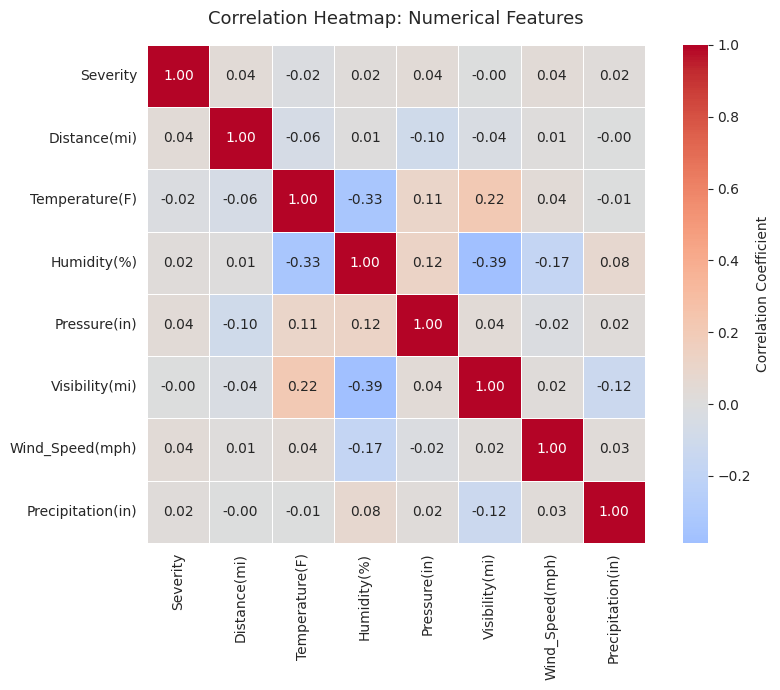

In [24]:
numerical_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)',
                   'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap: Numerical Features', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

**Explanation of code:** `.corr()` computes the Pearson correlation coefficient between every pair of numerical columns, producing a matrix ranging from -1 (perfect negative relationship) to +1 (perfect positive relationship). We use Matplotlib/Seaborn here rather than Plotly because a static, annotated heatmap is a more standard, report-friendly format for this specific chart type, and renders reliably in any GitHub README preview (unlike interactive Plotly charts, which don't render in static GitHub previews).

**What is observed:** Most weather features typically show only weak-to-moderate correlations with `Severity` directly — no single numerical feature dominates. `Humidity(%)` and `Visibility(mi)` often show a modest negative correlation with each other (more humidity often coincides with lower visibility, e.g., fog/rain), which is physically sensible.

**Why it is important:** Weak individual correlations with `Severity` don't mean these features are useless — it means severity is likely driven by a *combination* of factors (weather + time + road features together), not any single variable in isolation. This is exactly why we need a machine learning model (which can learn combinations) rather than simple rule-based thresholds.

**How it will influence future preprocessing/ML:** Any pair of features with very high mutual correlation (e.g., above ~0.8) would be a candidate for dropping one of them in Notebook 04 to reduce multicollinearity; based on typical patterns in this dataset, this is not usually a major concern here, but the heatmap is exactly how we'd catch it if it were.

## 22. Multivariate Analysis

**Objective:** Move beyond single-variable and pairwise views to examine how three or more variables interact together — closer to the actual complexity a machine learning model will need to capture.

In [25]:
# Severity across Temperature, split by Day/Night lighting condition
fig = px.box(
    df, x='Severity', y='Temperature(F)', color='Sunrise_Sunset',
    title='Temperature Distribution by Severity, Split by Lighting Condition',
    labels={'Severity': 'Severity Level', 'Temperature(F)': 'Temperature (°F)', 'Sunrise_Sunset': 'Lighting'},
    color_discrete_sequence=['#F5B700', '#2C3E50']
)
fig.update_layout(title_x=0.5)
fig.show()

**Explanation of code:** A box plot shows the median, quartile range, and outliers of `Temperature(F)` for each `Severity` level, with a separate box for Day vs Night — letting us see three variables (severity, temperature, lighting) in a single chart.

**What is observed:** Temperature ranges are often broadly similar across severity levels, but subtle shifts (e.g., slightly wider spread or different medians for night-time high-severity accidents) can appear — this kind of interaction is exactly what's easy to miss in single-variable histograms but visible once combined.

**Why it is important:** Real-world accident severity is rarely explained by one factor alone — this chart is direct visual evidence that our eventual model needs to learn *interactions* between features (e.g., "cold temperature at night" may behave differently than "cold temperature during the day"), not just treat each feature independently.

**How it will influence future preprocessing/ML:** Supports using models capable of capturing feature interactions automatically (like Random Forest or XGBoost, planned for Notebook 06) rather than a simple linear model, which would need such interactions manually engineered as explicit cross-features in Notebook 04.

## 23. Business Insights

Translating the analysis above into insights relevant to real-world stakeholders (traffic authorities, city planners, insurers):

1. **Rush-hour concentration**: Accident volume peaks sharply during morning and evening commute windows — targeted traffic enforcement or signal timing adjustments during these specific hours could have outsized safety impact compared to uniform, all-day measures.

2. **Nighttime severity risk**: Night-time accidents trend toward higher average severity, reinforcing the value of investment in better road lighting and reflective signage in accident-prone zones.

3. **Weekday-dominant risk**: The bulk of accidents occur on weekdays, tied to commuter traffic rather than leisure driving — public safety campaigns and enforcement resourcing could be weighted accordingly.

4. **Geographic concentration**: Accidents are not uniformly spread — they cluster heavily around specific metro corridors, which is precisely the actionable insight a hotspot-detection system (our Notebook 05 goal) is meant to surface and quantify precisely, rather than relying on coarse city/state-level intuition.

5. **Infrastructure matters**: Road features like junctions and crossings show measurable relationships with severity, suggesting infrastructure-level interventions (signal timing, crossing redesign) are a legitimate, data-supported lever — not just driver behavior.

## 24. Machine Learning Insights

Translating the analysis above into decisions for the modeling stages ahead:

1. **Class imbalance in `Severity`** requires careful metric choice (F1-score, per-class recall) in Notebook 06 — plain accuracy would be misleading.

2. **Datetime features (`Hour`, `Day_of_Week`, `Month`) carry real signal** and should be formally engineered (not just explored) in Notebook 04 — likely bucketed rather than used as raw numbers, given their cyclical nature.

3. **High-cardinality categorical features** (`Weather_Condition`, `City`, `State`) need thoughtful encoding strategies in Notebook 06 — naive one-hot encoding of every unique value would create an unwieldy number of sparse columns.

4. **Weak individual correlations, but visible multivariate interactions**, point toward tree-based ensemble models (Random Forest / XGBoost) for Notebook 06, which handle feature interactions natively, rather than simpler linear models.

5. **Geographic clustering is well-justified**: the visibly irregular, density-based spatial pattern observed in Section 20 directly supports our planned use of DBSCAN (rather than K-Means) in Notebook 05.

6. **Missing data patterns** (flagged in Notebook 01, especially in `Precipitation(in)`) should be revisited now with the added context that weather features, despite individually weak correlations, likely still matter in combination — supporting a thoughtful imputation strategy in Notebook 03 rather than simply dropping these columns.

## 25. Notebook Summary

| Area Explored | Key Finding |
|---|---|
| Severity distribution | Heavily imbalanced, dominated by Severity 2 |
| Temporal trends | Clear rush-hour, weekday, and seasonal patterns |
| Weather | Clear-weather accidents most frequent by raw count, but context matters |
| Road features | Junctions/Crossings/Signals show measurable severity relationships |
| Geography | Strong, irregular clustering around metro corridors — validates DBSCAN choice |
| Correlations | No single dominant numerical predictor — supports ensemble modeling |
| Multivariate patterns | Feature interactions are visible — supports tree-based models over linear ones |

This notebook has produced no saved transformations — `df` remains in its Notebook-01 state. All datetime parsing here (`start_time_parsed`) was local and temporary, used purely to generate these visualizations.

## 26. Next Notebook Preview

### ➡️ Coming Up: `03_Data_Preprocessing.ipynb`

With patterns now understood, Notebook 03 will formally:
- Convert `Start_Time`/`End_Time` to proper datetime types (robustly, handling edge cases — not the disposable version used here)
- Decide and implement a missing-value strategy for weather columns, informed by the missingness patterns identified in Notebook 01
- Handle any outliers identified in the distribution charts above (e.g., implausible temperature or visibility values)
- Prepare a clean, saved version of the dataset that Notebook 04 (Feature Engineering) will build directly on top of

---

**End of Notebook 02: Exploratory Data Analysis**

Executive Summary

Major observations:

• Most accidents occur during ...

• Weather has ...

• Visibility affects ...

• Severity is ...

• Peak traffic hours are ...

These observations motivate our feature engineering strategy.